In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 50)
np.random.seed(42)

import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [ ]:
kdd = fetch_kddcup99(percent10=True, as_frame=True)
kdd_df = kdd.frame.copy()

print("Shape:", kdd_df.shape)
kdd_df.head(8)

Shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'
5,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,59,59,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'
6,0,b'tcp',b'http',b'SF',212,1940,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,69,1.0,0.0,1.0,0.04,0.0,0.0,0.0,0.0,b'normal.'
7,0,b'tcp',b'http',b'SF',159,4087,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,11,79,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,b'normal.'


In [ ]:
def clean_text_col(s):

    if s.map(lambda v: isinstance(v, bytes)).any():
        s = s.map(lambda v: v.decode('utf-8') if isinstance(v, bytes) else v)
    return s.astype(str).str.replace(r"^b'(.*)'$", r'\1', regex=True)


for col in ['protocol_type', 'service', 'flag', 'labels']:
    kdd_df[col] = clean_text_col(kdd_df[col])

kdd_df['labels'] = kdd_df['labels'].str.rstrip('.')

print("Protocols:", kdd_df['protocol_type'].unique())
print("Flags:", kdd_df['flag'].unique()[:5], "...")
print("\nTop labels:")
print(kdd_df['labels'].value_counts().head())

Protocols: ['tcp' 'udp' 'icmp']
Flags: ['SF' 'S1' 'REJ' 'S2' 'S0'] ...

Top labels:
labels
smurf      280790
neptune    107201
normal      97278
back         2203
satan        1589
Name: count, dtype: int64


In [ ]:
attack_map = {
    'back':'dos','land':'dos','neptune':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
    'apache2':'dos','udpstorm':'dos','processtable':'dos','mailbomb':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'mscan':'probe','saint':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
    'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'named':'r2l','sendmail':'r2l','snmpgetattack':'r2l','snmpguess':'r2l',
    'worm':'r2l','xlock':'r2l','xsnoop':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r',
    'ps':'u2r','sqlattack':'u2r','xterm':'u2r','httptunnel':'u2r',
}

def to_category(label):
    return 'normal' if label == 'normal' else attack_map.get(label, 'unknown')

kdd_df['category'] = kdd_df['labels'].apply(to_category)

print(kdd_df['category'].value_counts())
print("\nUnmapped labels:", kdd_df[kdd_df['category']=='unknown']['labels'].unique())

category
dos       391458
normal     97278
probe       4107
r2l         1126
u2r           52
Name: count, dtype: int64

Unmapped labels: []


In [ ]:
raw_rows = len(kdd_df)
kdd_df = kdd_df.drop_duplicates().reset_index(drop=True)
clean_rows = len(kdd_df)

print(f"Raw rows:          {raw_rows:,}")
print(f"Duplicates removed:{raw_rows-clean_rows:,}  ({(raw_rows-clean_rows)/raw_rows:.1%})")
print(f"Remaining:         {clean_rows:,}")
print("\nAfter de-duplication:")
print(kdd_df['category'].value_counts())

Raw rows:          494,021
Duplicates removed:348,435  (70.5%)
Remaining:         145,586

After de-duplication:
category
normal    87832
dos       54572
probe      2131
r2l         999
u2r          52
Name: count, dtype: int64


In [ ]:
constant_cols = [c for c in kdd_df.columns if kdd_df[c].nunique() == 1]
print("Constant columns found:", constant_cols)

kdd_df = kdd_df.drop(columns=constant_cols)
print("Shape after drop:", kdd_df.shape)

Constant columns found: ['num_outbound_cmds', 'is_host_login']
Shape after drop: (145586, 41)


In [ ]:
cat_cols = ['protocol_type', 'service', 'flag']
encoders = {}

for col in cat_cols:
    n = kdd_df[col].nunique()
    le = LabelEncoder()
    kdd_df[col] = le.fit_transform(kdd_df[col])
    encoders[col] = le
    print(f"{col}: {n} unique values -> encoded 0 to {n-1}")

protocol_type: 3 unique values -> encoded 0 to 2
service: 66 unique values -> encoded 0 to 65
flag: 11 unique values -> encoded 0 to 10


In [ ]:
X = kdd_df.drop(columns=['labels', 'category'])
y = kdd_df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nClass proportions:")
print(pd.DataFrame({
    'train': y_train.value_counts(normalize=True).round(4),
    'test':  y_test.value_counts(normalize=True).round(4)
}))

Train: (101910, 39)  Test: (43676, 39)

Class proportions:
           train    test
category                
normal    0.6033  0.6033
dos       0.3748  0.3749
probe     0.0146  0.0146
r2l       0.0069  0.0069
u2r       0.0004  0.0003


In [ ]:
col_names = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty']

base = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/"
nsl_train = pd.read_csv(base + "KDDTrain%2B.txt", names=col_names)
nsl_test  = pd.read_csv(base + "KDDTest%2B.txt",  names=col_names)

print("Train:", nsl_train.shape, " Test:", nsl_test.shape)
nsl_train.head(2)

Train: (125973, 43)  Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15


In [ ]:
for df in (nsl_train, nsl_test):
    df['category'] = df['label'].apply(to_category)

print("Unmapped in train:", (nsl_train['category']=='unknown').sum())
print("Unmapped in test: ", (nsl_test['category']=='unknown').sum())

unseen = sorted(set(nsl_test['label']) - set(nsl_train['label']))
print(f"\nAttack types in TEST but never in TRAIN: {len(unseen)}")
print(unseen)

Unmapped in train: 0
Unmapped in test:  0

Attack types in TEST but never in TRAIN: 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


In [ ]:
nsl_const = [c for c in nsl_train.columns if nsl_train[c].nunique() == 1]
print("Constant columns:", nsl_const)
nsl_train = nsl_train.drop(columns=nsl_const)
nsl_test  = nsl_test.drop(columns=nsl_const)

nsl_encoders = {}
for col in cat_cols:
    combined = pd.concat([nsl_train[col], nsl_test[col]]).unique()
    le = LabelEncoder().fit(combined)
    nsl_train[col] = le.transform(nsl_train[col])
    nsl_test[col]  = le.transform(nsl_test[col])
    nsl_encoders[col] = le
    print(f"{col}: {len(combined)} values (train+test combined)")

print("\nTrain:", nsl_train.shape, " Test:", nsl_test.shape)

Constant columns: ['num_outbound_cmds']
protocol_type: 3 values (train+test combined)
service: 70 values (train+test combined)
flag: 11 values (train+test combined)

Train: (125973, 43)  Test: (22544, 43)


In [ ]:

for col in ['is_host_login']:
    if col in nsl_train.columns:
        nsl_train = nsl_train.drop(columns=col)
        nsl_test  = nsl_test.drop(columns=col)

print("NSL train:", nsl_train.shape, " NSL test:", nsl_test.shape)

kdd_features = set(X.columns)
nsl_features = set(nsl_train.columns) - {'label', 'difficulty', 'category'}
print("\nFeature counts — KDD'99:", len(kdd_features), "| NSL-KDD:", len(nsl_features))
print("Only in KDD'99:", kdd_features - nsl_features)
print("Only in NSL-KDD:", nsl_features - kdd_features)

NSL train: (125973, 42)  NSL test: (22544, 42)

Feature counts — KDD'99: 39 | NSL-KDD: 39
Only in KDD'99: set()
Only in NSL-KDD: set()


In [ ]:
print("=== KDD'99 ===")
print("Rows after cleaning:", f"{len(kdd_df):,}")
print(kdd_df['category'].value_counts().to_string())

print("\n=== NSL-KDD ===")
print("Train rows:", f"{len(nsl_train):,}", "| Test rows:", f"{len(nsl_test):,}")
print("Duplicate rows in train:", nsl_train.duplicated().sum())
print("Unseen attack types:", len(unseen))

=== KDD'99 ===
Rows after cleaning: 145,586
category
normal    87832
dos       54572
probe      2131
r2l         999
u2r          52

=== NSL-KDD ===
Train rows: 125,973 | Test rows: 22,544
Duplicate rows in train: 0
Unseen attack types: 17


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

kdd_df.to_csv('/content/drive/MyDrive/kdd99_clean.csv', index=False)
nsl_train.to_csv('/content/drive/MyDrive/nsl_train_clean.csv', index=False)
nsl_test.to_csv('/content/drive/MyDrive/nsl_test_clean.csv', index=False)
print("Saved 3 files to MyDrive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 3 files to MyDrive.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import time
print("Ready.")

Ready.


In [ ]:
y_train_bin = (y_train != 'normal').astype(int)
y_test_bin  = (y_test  != 'normal').astype(int)

print("Train — attack:", y_train_bin.sum(), "| normal:", (y_train_bin==0).sum())
print("Test  — attack:", y_test_bin.sum(),  "| normal:", (y_test_bin==0).sum())
print("Attack proportion:", round(y_train_bin.mean(), 4))

Train — attack: 40428 | normal: 61482
Test  — attack: 17326 | normal: 26350
Attack proportion: 0.3967


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

i = X_train.columns.get_loc('src_bytes')
print("Scaled shape:", X_train_scaled.shape)
print(f"src_bytes raw range:    {X_train['src_bytes'].min():,} to {X_train['src_bytes'].max():,}")
print(f"src_bytes scaled range: {X_train_scaled[:,i].min():.2f} to {X_train_scaled[:,i].max():.2f}")

Scaled shape: (101910, 39)
src_bytes raw range:    0 to 5,135,678
src_bytes scaled range: -0.03 to 47.98


In [ ]:
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)
print("dtypes:", X_train_scaled.dtype, X_test_scaled.dtype)

dtypes: float32 float32


In [ ]:
print(f"src_bytes across full dataset: {kdd_df['src_bytes'].min():,} to {kdd_df['src_bytes'].max():,}")


src_bytes across full dataset: 0 to 693,375,640


In [ ]:
models, results = {}, []

specs = [
    ('Decision Tree',       DecisionTreeClassifier(random_state=42), False),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), False),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), True),
]

for name, model, scaled in specs:
    Xtr = X_train_scaled if scaled else X_train
    Xte = X_test_scaled  if scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train_bin)
    pred = model.predict(Xte)
    el = time.time() - t0

    models[name] = (model, scaled)
    results.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test_bin, pred),
        'Precision': precision_score(y_test_bin, pred),
        'Recall':    recall_score(y_test_bin, pred),
        'Macro-F1':  f1_score(y_test_bin, pred, average='macro'),
        'Time(s)':   round(el, 1),
    })
    print(f"{name}: done in {el:.1f}s")

baseline_df = pd.DataFrame(results).set_index('Model').round(4)
baseline_df

Decision Tree: done in 1.9s
Random Forest: done in 14.0s
Logistic Regression: done in 2.8s


,Accuracy,Precision,Recall,Macro-F1,Time(s)
Model,,,,,
Decision Tree,0.9992,0.9990,0.9989,0.9991,1.9
Random Forest,0.9992,0.9994,0.9986,0.9992,14.0
Logistic Regression,0.9882,0.9903,0.9799,0.9877,2.8


In [ ]:
fpr_rows = []
for name, (model, scaled) in models.items():
    Xte = X_test_scaled if scaled else X_test
    pred = model.predict(Xte)
    tn, fp, fn, tp = confusion_matrix(y_test_bin, pred).ravel()
    fpr = fp / (fp + tn)
    fpr_rows.append({'Model': name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp, 'FPR': round(fpr, 5)})

    print(f"\n=== {name} ===")
    print(f"  Normal called normal (TN):  {tn:,}")
    print(f"  Normal called attack (FP):  {fp:,}")
    print(f"  Attack MISSED       (FN):  {fn:,}")
    print(f"  Attack caught       (TP):  {tp:,}")
    print(f"  False Positive Rate:        {fpr:.5f}")

fpr_df = pd.DataFrame(fpr_rows).set_index('Model')


=== Decision Tree ===
  Normal called normal (TN):  26,332
  Normal called attack (FP):  18
  Attack MISSED       (FN):  19
  Attack caught       (TP):  17,307
  False Positive Rate:        0.00068

=== Random Forest ===
  Normal called normal (TN):  26,339
  Normal called attack (FP):  11
  Attack MISSED       (FN):  24
  Attack caught       (TP):  17,302
  False Positive Rate:        0.00042

=== Logistic Regression ===
  Normal called normal (TN):  26,184
  Normal called attack (FP):  166
  Attack MISSED       (FN):  349
  Attack caught       (TP):  16,977
  False Positive Rate:        0.00630


In [ ]:
import pickle, os
os.makedirs('/content/drive/MyDrive/adm_project', exist_ok=True)

baseline_df.to_csv('/content/drive/MyDrive/adm_project/baseline_results.csv')
fpr_df.to_csv('/content/drive/MyDrive/adm_project/baseline_confusion.csv')

with open('/content/drive/MyDrive/adm_project/models.pkl', 'wb') as f:
    pickle.dump({'models': models, 'scaler': scaler,
                 'feature_names': list(X_train.columns)}, f)

print("Saved to MyDrive/adm_project/:")
print("  baseline_results.csv    <- metrics table for the report")
print("  baseline_confusion.csv  <- TN/FP/FN/TP + FPR")
print("  models.pkl              <- trained models, reload instead of retraining")
baseline_df

Saved to MyDrive/adm_project/:
  baseline_results.csv    <- metrics table for the report
  baseline_confusion.csv  <- TN/FP/FN/TP + FPR
  models.pkl              <- trained models, reload instead of retraining


,Accuracy,Precision,Recall,Macro-F1,Time(s)
Model,,,,,
Decision Tree,0.9992,0.9990,0.9989,0.9991,1.9
Random Forest,0.9992,0.9994,0.9986,0.9992,14.0
Logistic Regression,0.9882,0.9903,0.9799,0.9877,2.8


In [ ]:
print("BASELINE REFERENCE — clean data, no attack")
print("="*55)
print(baseline_df[['Accuracy','Precision','Recall','Macro-F1']].to_string())
print("\nFalse negatives (attacks missed with no adversary):")
for name, r in fpr_df.iterrows():
    print(f"  {name}: {r['FN']}")
print("\nMacro-F1 values above are what metric 8 subtracts from.")

BASELINE REFERENCE — clean data, no attack
                     Accuracy  Precision  Recall  Macro-F1
Model                                                     
Decision Tree          0.9992     0.9990  0.9989    0.9991
Random Forest          0.9992     0.9994  0.9986    0.9992
Logistic Regression    0.9882     0.9903  0.9799    0.9877

False negatives (attacks missed with no adversary):
  Decision Tree: 19.0
  Random Forest: 24.0
  Logistic Regression: 349.0

Macro-F1 values above are what metric 8 subtracts from.


In [ ]:
!pip install adversarial-robustness-toolbox --quiet
print("ART installed.")


ART installed.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

n_features = X_train_scaled.shape[1]

class SurrogateMLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

surrogate = SurrogateMLP(n_features).to(device)
print(f"Input features: {n_features}")
print(surrogate)

Device: cpu
Input features: 39
SurrogateMLP(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
Xtr_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
ytr_t = torch.tensor(y_train_bin.values, dtype=torch.long).to(device)
Xte_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

torch.manual_seed(42)
opt = optim.Adam(surrogate.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()
batch = 256

for epoch in range(15):
    surrogate.train()
    perm = torch.randperm(len(Xtr_t))
    total = 0.0
    for i in range(0, len(Xtr_t), batch):
        idx = perm[i:i+batch]
        opt.zero_grad()
        loss = lossfn(surrogate(Xtr_t[idx]), ytr_t[idx])
        loss.backward(); opt.step()
        total += loss.item()
    if (epoch+1) % 5 == 0:
        surrogate.eval()
        with torch.no_grad():
            acc = (surrogate(Xte_t).argmax(1).cpu().numpy() == y_test_bin.values).mean()
        print(f"epoch {epoch+1:2d} | test acc {acc:.4f}")

surrogate.eval()
with torch.no_grad():
    surr_pred = surrogate(Xte_t).argmax(1).cpu().numpy()
surr_acc = (surr_pred == y_test_bin.values).mean()
surr_f1  = f1_score(y_test_bin, surr_pred, average='macro')
print(f"\nSurrogate clean accuracy: {surr_acc:.4f}")
print(f"Surrogate clean macro-F1: {surr_f1:.4f}")
print(f"Compare — RF macro-F1:    0.9992")

epoch  5 | test acc 0.9969
epoch 10 | test acc 0.9978
epoch 15 | test acc 0.9980

Surrogate clean accuracy: 0.9980
Surrogate clean macro-F1: 0.9979
Compare — RF macro-F1:    0.9992


In [ ]:
from art.estimators.classification import PyTorchClassifier

clip_min = float(X_train_scaled.min())
clip_max = float(X_train_scaled.max())

art_clf = PyTorchClassifier(
    model=surrogate,
    loss=nn.CrossEntropyLoss(),
    optimizer=opt,
    input_shape=(n_features,),
    nb_classes=2,
    clip_values=(clip_min, clip_max),
    device_type='gpu' if torch.cuda.is_available() else 'cpu',
)

attack_mask = (y_test_bin.values == 1)
X_att_all = X_test_scaled[attack_mask]
with torch.no_grad():
    p = surrogate(torch.tensor(X_att_all, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
correct = p == 1
X_attack = X_att_all[correct]
attack_row_ids = np.where(attack_mask)[0][correct]

print(f"Attack records in test set:      {attack_mask.sum():,}")
print(f"Correctly detected by surrogate: {correct.sum():,}")
print(f"Will be attacked:                {len(X_attack):,}")
print(f"Clip range (scaled): {clip_min:.2f} to {clip_max:.2f}")

Attack records in test set:      17,326
Correctly detected by surrogate: 17,283
Will be attacked:                17,283
Clip range (scaled): -3.42 to 247.28


In [ ]:
from art.attacks.evasion import FastGradientMethod

fgsm_results, adv_store = [], {}

for eps in [0.05, 0.1, 0.2, 0.5, 1.0]:
    t0 = time.time()
    atk = FastGradientMethod(estimator=art_clf, eps=eps)
    X_adv = atk.generate(x=X_attack)

    with torch.no_grad():
        pa = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()

    flipped = int((pa == 0).sum())
    rate = flipped / len(X_attack)
    fgsm_results.append({'attack':'FGSM','epsilon':eps,'flipped':flipped,
                         'total':len(X_attack),'flip_rate':round(rate,4),
                         'seconds':round(time.time()-t0,1)})
    adv_store[f'fgsm_{eps}'] = X_adv
    print(f"eps={eps:<5} flipped {flipped:>6,}/{len(X_attack):,} = {rate:7.2%}  ({time.time()-t0:.1f}s)")

fgsm_df = pd.DataFrame(fgsm_results)
fgsm_df

eps=0.05  flipped     64/17,283 =   0.37%  (1.0s)
eps=0.1   flipped    203/17,283 =   1.17%  (1.1s)
eps=0.2   flipped    904/17,283 =   5.23%  (1.0s)
eps=0.5   flipped 16,739/17,283 =  96.85%  (1.0s)
eps=1.0   flipped 17,040/17,283 =  98.59%  (1.0s)


,attack,epsilon,flipped,total,flip_rate,seconds
0,FGSM,0.05,64,17283,0.0037,1.0
1,FGSM,0.10,203,17283,0.0117,1.1
2,FGSM,0.20,904,17283,0.0523,1.0
3,FGSM,0.50,16739,17283,0.9685,1.0
4,FGSM,1.00,17040,17283,0.9859,1.0


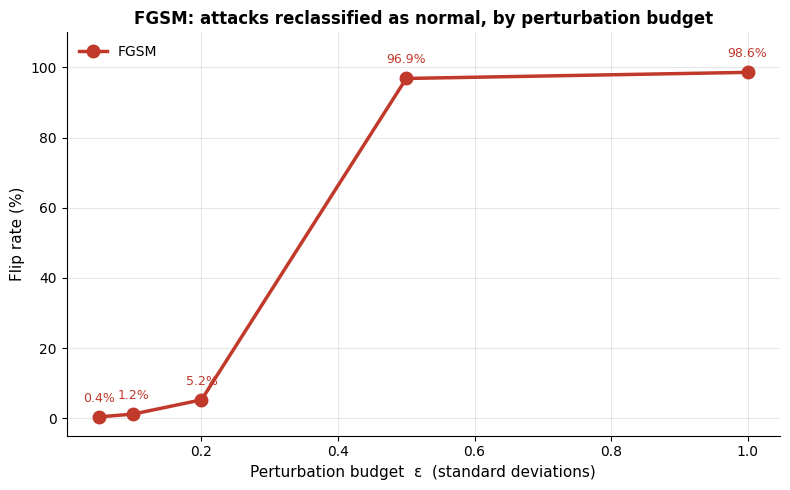

Saved to MyDrive/adm_project/fgsm_curve.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(fgsm_df['epsilon'], fgsm_df['flip_rate']*100,
        marker='o', linewidth=2.5, markersize=9, color='#C0392B', label='FGSM')

for _, r in fgsm_df.iterrows():
    ax.annotate(f"{r['flip_rate']*100:.1f}%",
                (r['epsilon'], r['flip_rate']*100),
                textcoords="offset points", xytext=(0, 11),
                ha='center', fontsize=9, color='#C0392B')

ax.set_xlabel('Perturbation budget  ε  (standard deviations)', fontsize=11)
ax.set_ylabel('Flip rate (%)', fontsize=11)
ax.set_title('FGSM: attacks reclassified as normal, by perturbation budget',
             fontsize=12, fontweight='bold')
ax.set_ylim(-5, 110)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adm_project/fgsm_curveepdiff.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved to MyDrive/adm_project/fgsm_curve.png")

In [ ]:
fine_results = []
for eps in [0.25, 0.30, 0.35, 0.40, 0.45]:
    atk = FastGradientMethod(estimator=art_clf, eps=eps)
    X_adv = atk.generate(x=X_attack)
    with torch.no_grad():
        pa = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
    flipped = int((pa == 0).sum())
    rate = flipped / len(X_attack)
    fine_results.append({'attack':'FGSM','epsilon':eps,'flipped':flipped,
                         'total':len(X_attack),'flip_rate':round(rate,4)})
    adv_store[f'fgsm_{eps}'] = X_adv
    print(f"eps={eps:<5} flipped {flipped:>6,}/{len(X_attack):,} = {rate:7.2%}")

fgsm_df = pd.concat([fgsm_df, pd.DataFrame(fine_results)]).sort_values('epsilon').reset_index(drop=True)
fgsm_df

eps=0.25  flipped  1,792/17,283 =  10.37%
eps=0.3   flipped  5,431/17,283 =  31.42%
eps=0.35  flipped 11,703/17,283 =  67.71%
eps=0.4   flipped 16,478/17,283 =  95.34%
eps=0.45  flipped 16,711/17,283 =  96.69%


,attack,epsilon,flipped,total,flip_rate,seconds
0,FGSM,0.05,64,17283,0.0037,1.0
1,FGSM,0.10,203,17283,0.0117,1.1
2,FGSM,0.20,904,17283,0.0523,1.0
3,FGSM,0.25,1792,17283,0.1037,NaN
4,FGSM,0.30,5431,17283,0.3142,NaN
5,FGSM,0.35,11703,17283,0.6771,NaN
6,FGSM,0.40,16478,17283,0.9534,NaN
7,FGSM,0.45,16711,17283,0.9669,NaN
8,FGSM,0.50,16739,17283,0.9685,1.0
9,FGSM,1.00,17040,17283,0.9859,1.0


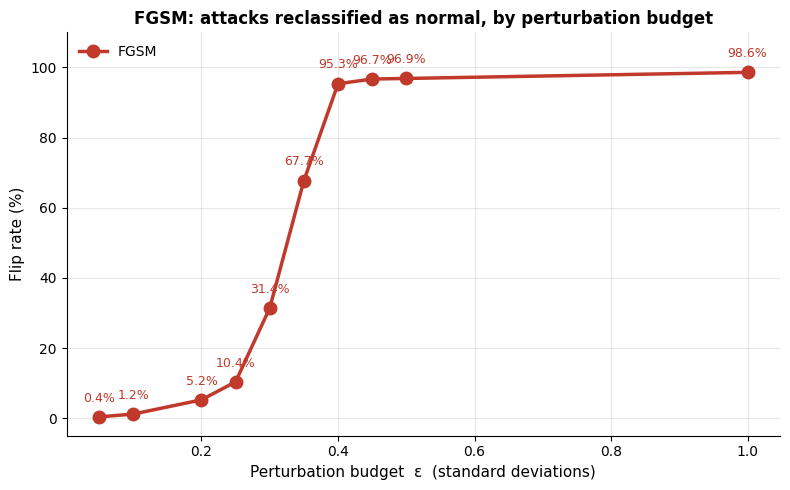

Saved to MyDrive/adm_project/fgsm_curve.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(fgsm_df['epsilon'], fgsm_df['flip_rate']*100,
        marker='o', linewidth=2.5, markersize=9, color='#C0392B', label='FGSM')

for _, r in fgsm_df.iterrows():
    ax.annotate(f"{r['flip_rate']*100:.1f}%",
                (r['epsilon'], r['flip_rate']*100),
                textcoords="offset points", xytext=(0, 11),
                ha='center', fontsize=9, color='#C0392B')

ax.set_xlabel('Perturbation budget  ε  (standard deviations)', fontsize=11)
ax.set_ylabel('Flip rate (%)', fontsize=11)
ax.set_title('FGSM: attacks reclassified as normal, by perturbation budget',
             fontsize=12, fontweight='bold')
ax.set_ylim(-5, 110)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adm_project/fgsm_curve.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved to MyDrive/adm_project/fgsm_curve.png")

In [ ]:
fgsm_df.to_csv('/content/drive/MyDrive/adm_project/approach1_fgsm.csv', index=False)
np.save('/content/drive/MyDrive/adm_project/X_attack.npy', X_attack)
np.save('/content/drive/MyDrive/adm_project/attack_row_ids.npy', attack_row_ids)
print("Saved FGSM results and attack set.")

Saved FGSM results and attack set.


In [ ]:
torch.save({'model': surrogate.state_dict(),
            'opt': opt.state_dict()},
           '/content/drive/MyDrive/adm_project/surrogate_full.pt')

In [ ]:
from art.attacks.evasion import ProjectedGradientDescent

pgd_results = []
for eps in [0.05, 0.1, 0.2, 0.3, 0.5]:
    t0 = time.time()
    atk = ProjectedGradientDescent(estimator=art_clf, eps=eps,
                                   eps_step=eps/10, max_iter=40, verbose=False)
    X_adv = atk.generate(x=X_attack)
    with torch.no_grad():
        pa = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
    flipped = int((pa == 0).sum())
    rate = flipped / len(X_attack)
    pgd_results.append({'attack':'PGD','epsilon':eps,'flipped':flipped,
                        'total':len(X_attack),'flip_rate':round(rate,4),
                        'seconds':round(time.time()-t0,1)})
    adv_store[f'pgd_{eps}'] = X_adv
    print(f"eps={eps:<5} flipped {flipped:>6,}/{len(X_attack):,} = {rate:7.2%}  ({time.time()-t0:.1f}s)")

pgd_df = pd.DataFrame(pgd_results)
pgd_df

eps=0.05  flipped     71/17,283 =   0.41%  (38.0s)
eps=0.1   flipped    269/17,283 =   1.56%  (39.5s)
eps=0.2   flipped  1,043/17,283 =   6.03%  (40.7s)
eps=0.3   flipped  7,821/17,283 =  45.25%  (42.1s)
eps=0.5   flipped 16,812/17,283 =  97.27%  (43.1s)


,attack,epsilon,flipped,total,flip_rate,seconds
0,PGD,0.05,71,17283,0.0041,38.0
1,PGD,0.10,269,17283,0.0156,39.5
2,PGD,0.20,1043,17283,0.0603,40.7
3,PGD,0.30,7821,17283,0.4525,42.1
4,PGD,0.50,16812,17283,0.9727,43.1


In [ ]:
for eps in [0.35, 0.40, 0.45]:
    t0 = time.time()
    atk = ProjectedGradientDescent(estimator=art_clf, eps=eps,
                                   eps_step=eps/10, max_iter=40, verbose=False)
    X_adv = atk.generate(x=X_attack)
    with torch.no_grad():
        pa = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
    flipped = int((pa == 0).sum())
    rate = flipped / len(X_attack)
    pgd_results.append({'attack':'PGD','epsilon':eps,'flipped':flipped,
                        'total':len(X_attack),'flip_rate':round(rate,4),
                        'seconds':round(time.time()-t0,1)})
    adv_store[f'pgd_{eps}'] = X_adv
    print(f"eps={eps:<5} flipped {flipped:>6,}/{len(X_attack):,} = {rate:7.2%}")

pgd_df = pd.DataFrame(pgd_results).sort_values('epsilon').reset_index(drop=True)
pgd_df.to_csv('/content/drive/MyDrive/adm_project/approach1_pgd.csv', index=False)
pgd_df

eps=0.35  flipped 15,415/17,283 =  89.19%
eps=0.4   flipped 16,764/17,283 =  97.00%
eps=0.45  flipped 16,801/17,283 =  97.21%


,attack,epsilon,flipped,total,flip_rate,seconds
0,PGD,0.05,71,17283,0.0041,38.0
1,PGD,0.10,269,17283,0.0156,39.5
2,PGD,0.20,1043,17283,0.0603,40.7
3,PGD,0.30,7821,17283,0.4525,42.1
4,PGD,0.35,15415,17283,0.8919,43.3
5,PGD,0.40,16764,17283,0.9700,42.7
6,PGD,0.45,16801,17283,0.9721,38.6
7,PGD,0.50,16812,17283,0.9727,43.1


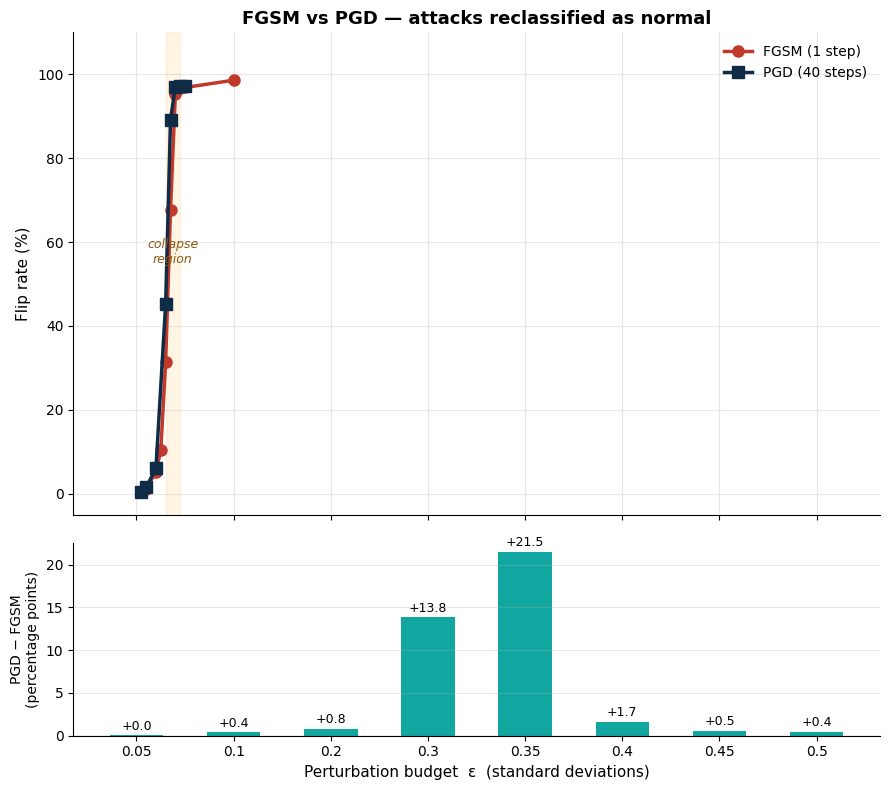


Gap at each shared epsilon:
  eps=0.05  PGD advantage: +0.04 pp
  eps=0.1   PGD advantage: +0.39 pp
  eps=0.2   PGD advantage: +0.80 pp
  eps=0.3   PGD advantage: +13.83 pp
  eps=0.35  PGD advantage: +21.48 pp
  eps=0.4   PGD advantage: +1.66 pp
  eps=0.45  PGD advantage: +0.52 pp
  eps=0.5   PGD advantage: +0.42 pp


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8),
                               gridspec_kw={'height_ratios': [3, 1.2]}, sharex=True)


ax1.plot(fgsm_df['epsilon'], fgsm_df['flip_rate']*100,
         marker='o', lw=2.5, ms=8, color='#C0392B', label='FGSM (1 step)')
ax1.plot(pgd_df['epsilon'], pgd_df['flip_rate']*100,
         marker='s', lw=2.5, ms=8, color='#0F2B46', label='PGD (40 steps)')

ax1.set_ylabel('Flip rate (%)', fontsize=11)
ax1.set_title('FGSM vs PGD — attacks reclassified as normal',
              fontsize=13, fontweight='bold')
ax1.set_ylim(-5, 110)
ax1.grid(alpha=0.3)
ax1.legend(frameon=False, fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.axvspan(0.30, 0.45, alpha=0.10, color='orange')
ax1.text(0.375, 55, 'collapse\nregion', ha='center', fontsize=9,
         color='#8A5A12', style='italic')


shared = sorted(set(fgsm_df['epsilon']) & set(pgd_df['epsilon']))
f_map = dict(zip(fgsm_df['epsilon'], fgsm_df['flip_rate']))
p_map = dict(zip(pgd_df['epsilon'], pgd_df['flip_rate']))
gaps = [(p_map[e] - f_map[e])*100 for e in shared]

bars = ax2.bar([str(e) for e in shared], gaps, color='#12A6A0', width=0.55)
ax2.bar_label(bars, fmt='%+.1f', fontsize=9, padding=2)
ax2.set_ylabel('PGD − FGSM\n(percentage points)', fontsize=10)
ax2.set_xlabel('Perturbation budget  ε  (standard deviations)', fontsize=11)
ax2.axhline(0, color='#888', lw=0.8)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adm_project/fgsm_vs_pgd.png', dpi=180, bbox_inches='tight')
plt.show()

print("\nGap at each shared epsilon:")
for e, g in zip(shared, gaps):
    print(f"  eps={e:<5} PGD advantage: {g:+.2f} pp")

In [ ]:
from art.attacks.evasion import SaliencyMapMethod

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_attack), size=1000, replace=False)
X_jsma_in = X_attack[sample_idx]
jsma_row_ids = attack_row_ids[sample_idx]

jsma_results = []
for theta in [0.3, 0.5, 1.0]:
    t0 = time.time()
    atk = SaliencyMapMethod(classifier=art_clf, theta=theta, gamma=0.1, verbose=False)
    X_adv = atk.generate(x=X_jsma_in)
    with torch.no_grad():
        pa = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()

    flipped = int((pa == 0).sum())
    rate = flipped / len(X_jsma_in)
    changed = (np.abs(X_adv - X_jsma_in) > 1e-6).sum(axis=1)
    jsma_results.append({'attack':'JSMA','theta':theta,'gamma':0.1,
                         'flipped':flipped,'total':len(X_jsma_in),
                         'flip_rate':round(rate,4),
                         'mean_features_changed':round(changed.mean(),2),
                         'seconds':round(time.time()-t0,1)})
    adv_store[f'jsma_{theta}'] = X_adv
    print(f"theta={theta:<4} flipped {flipped:>4}/1000 = {rate:6.2%} | "
          f"avg {changed.mean():.1f} features changed ({time.time()-t0:.0f}s)")

jsma_df = pd.DataFrame(jsma_results)
np.save('/content/drive/MyDrive/adm_project/jsma_row_ids.npy', jsma_row_ids)
jsma_df.to_csv('/content/drive/MyDrive/adm_project/approach1_jsma.csv', index=False)
jsma_df

theta=0.3  flipped  915/1000 = 91.50% | avg 3.1 features changed (18s)
theta=0.5  flipped  938/1000 = 93.80% | avg 3.1 features changed (13s)
theta=1.0  flipped  970/1000 = 97.00% | avg 3.0 features changed (8s)


,attack,theta,gamma,flipped,total,flip_rate,mean_features_changed,seconds
0,JSMA,0.3,0.1,915,1000,0.915,3.07,18.4
1,JSMA,0.5,0.1,938,1000,0.938,3.08,12.8
2,JSMA,1.0,0.1,970,1000,0.970,3.01,8.2


In [ ]:
X_adv_jsma = adv_store['jsma_1.0']
diff = np.abs(X_adv_jsma - X_jsma_in) > 1e-6

feat_counts = pd.Series(diff.sum(axis=0), index=X_train.columns)
feat_pct = (feat_counts / len(X_jsma_in) * 100).sort_values(ascending=False)

print("Features JSMA modified, % of the 1,000 records:\n")
print(feat_pct.head(12).round(1).to_string())
print(f"\nFeatures never touched: {(feat_counts==0).sum()} of {len(feat_counts)}")

feat_pct.to_csv('/content/drive/MyDrive/adm_project/jsma_feature_usage.csv')

Features JSMA modified, % of the 1,000 records:

dst_bytes                      96.4
logged_in                      96.1
same_srv_rate                  88.4
num_root                        5.0
dst_host_srv_diff_host_rate     4.7
protocol_type                   4.1
srv_count                       2.4
dst_host_srv_count              2.0
service                         0.7
flag                            0.5
duration                        0.2
dst_host_same_srv_rate          0.1

Features never touched: 25 of 39


In [ ]:
transfer_rows = []
eval_eps = [0.2, 0.3, 0.35, 0.5]

for atk_name, prefix in [('FGSM','fgsm'), ('PGD','pgd')]:
    for eps in eval_eps:
        key = f'{prefix}_{eps}'
        if key not in adv_store:
            continue
        X_adv = adv_store[key]

        for model_name, (model, needs_scaling) in models.items():
            if not needs_scaling and model_name != 'Logistic Regression':
                X_adv_raw = scaler.inverse_transform(X_adv.astype(np.float64))
                pred = model.predict(X_adv_raw)
                clean_pred = model.predict(scaler.inverse_transform(X_attack.astype(np.float64)))
            else:
                pred = model.predict(X_adv)
                clean_pred = model.predict(X_attack)

            caught_before = (clean_pred == 1)
            flipped = ((clean_pred == 1) & (pred == 0)).sum()
            rate = flipped / caught_before.sum() if caught_before.sum() else 0

            transfer_rows.append({
                'attack': atk_name, 'epsilon': eps, 'target_model': model_name,
                'caught_clean': int(caught_before.sum()),
                'flipped': int(flipped), 'transfer_flip_rate': round(rate, 4)})

transfer_df = pd.DataFrame(transfer_rows)
transfer_df.to_csv('/content/drive/MyDrive/adm_project/approach1_transfer.csv', index=False)
print(transfer_df.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

attack  epsilon        target_model  caught_clean  flipped  transfer_flip_rate
  FGSM     0.20       Decision Tree         17273     2990              0.1731
  FGSM     0.20       Random Forest         17279     3227              0.1868
  FGSM     0.20 Logistic Regression         16965      739              0.0436
  FGSM     0.30       Decision Tree         17273     3045              0.1763
  FGSM     0.30       Random Forest         17279     3388              0.1961
  FGSM     0.30 Logistic Regression         16965      941              0.0555
  FGSM     0.35       Decision Tree         17273     2920              0.1690
  FGSM     0.35       Random Forest         17279     3326              0.1925
  FGSM     0.35 Logistic Regression         16965     1258              0.0742
  FGSM     0.50       Decision Tree         17273     2255              0.1306
  FGSM     0.50       Random Forest         17279     3513              0.2033
  FGSM     0.50 Logistic Regression         16965   

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
X_jsma_raw = scaler.inverse_transform(X_jsma_in.astype(np.float64))
jsma_rows = []
for theta in [0.3, 0.5, 1.0]:
    key = f'jsma_{theta}'
    if key not in adv_store:
        print(f"MISSING: {key}"); continue
    X_adv_raw = scaler.inverse_transform(adv_store[key].astype(np.float64))
    for mname, (model, scaled) in models.items():
        if scaled:
            cp, ap = model.predict(X_jsma_in), model.predict(adv_store[key])
        else:
            cp, ap = model.predict(X_jsma_raw), model.predict(X_adv_raw)
        caught = (cp == 1)
        flipped = int(((cp == 1) & (ap == 0)).sum())
        jsma_rows.append({'attack':'JSMA','theta':theta,'target_model':mname,
                          'caught_clean':int(caught.sum()),'flipped':flipped,
                          'transfer_flip_rate':round(flipped/caught.sum(),4)})

jsma_transfer = pd.DataFrame(jsma_rows)
print(jsma_transfer.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

attack  theta        target_model  caught_clean  flipped  transfer_flip_rate
  JSMA    0.3       Decision Tree           999       23              0.0230
  JSMA    0.3       Random Forest          1000        7              0.0070
  JSMA    0.3 Logistic Regression           979       28              0.0286
  JSMA    0.5       Decision Tree           999       24              0.0240
  JSMA    0.5       Random Forest          1000        8              0.0080
  JSMA    0.5 Logistic Regression           979       31              0.0317
  JSMA    1.0       Decision Tree           999       28              0.0280
  JSMA    1.0       Random Forest          1000       10              0.0100
  JSMA    1.0 Logistic Regression           979       33              0.0337


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

X_attack_raw = scaler.inverse_transform(X_attack.astype(np.float64))
rf_model = models['Random Forest'][0]
clean_pred_rf = rf_model.predict(X_attack_raw)
rf = rf_model
clean_rf = clean_pred_rf

big_rows = []
for eps in [0.75, 1.0, 1.5, 2.0, 3.0]:
    atk = FastGradientMethod(estimator=art_clf, eps=eps)
    X_adv = atk.generate(x=X_attack)
    adv_store[f'fgsm_{eps}'] = X_adv
    X_adv_raw = scaler.inverse_transform(X_adv.astype(np.float64))
    ap = rf_model.predict(X_adv_raw)
    flipped = int(((clean_pred_rf == 1) & (ap == 0)).sum())
    rate = flipped / (clean_pred_rf == 1).sum()
    big_rows.append({'epsilon': eps, 'flipped': flipped, 'rate': round(rate, 4)})
    print(f"eps={eps:<5} RF transfer flipped {flipped:>5,} = {rate:.2%}")

pd.DataFrame(big_rows)

eps=0.75  RF transfer flipped 4,010 = 23.21%
eps=1.0   RF transfer flipped 9,327 = 53.98%
eps=1.5   RF transfer flipped 16,669 = 96.47%
eps=2.0   RF transfer flipped 16,725 = 96.79%
eps=3.0   RF transfer flipped 16,879 = 97.69%


,epsilon,flipped,rate
0,0.75,4010,0.2321
1,1.00,9327,0.5398
2,1.50,16669,0.9647
3,2.00,16725,0.9679
4,3.00,16879,0.9769


In [ ]:
import pickle
with open('/content/drive/MyDrive/adm_project/adversarial_records.pkl', 'wb') as f:
    pickle.dump({'adv_store': adv_store, 'X_attack': X_attack,
                 'attack_row_ids': attack_row_ids,
                 'jsma_row_ids': jsma_row_ids, 'jsma_sample_idx': sample_idx,
                 'feature_names': list(X_train.columns)}, f)
print("Keys saved:", sorted(adv_store.keys()))

Keys saved: ['fgsm_0.05', 'fgsm_0.1', 'fgsm_0.2', 'fgsm_0.25', 'fgsm_0.3', 'fgsm_0.35', 'fgsm_0.4', 'fgsm_0.45', 'fgsm_0.5', 'fgsm_0.75', 'fgsm_1.0', 'fgsm_1.5', 'fgsm_2.0', 'fgsm_3.0', 'jsma_0.3', 'jsma_0.5', 'jsma_1.0', 'pgd_0.05', 'pgd_0.1', 'pgd_0.2', 'pgd_0.3', 'pgd_0.35', 'pgd_0.4', 'pgd_0.45', 'pgd_0.5']


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

X_attack_raw = scaler.inverse_transform(X_attack.astype(np.float64))
clean_preds = {}
for mname, (model, scaled) in models.items():
    clean_preds[mname] = model.predict(X_attack if scaled else X_attack_raw)

rows = []
for eps in [0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    key = f'fgsm_{eps}'
    if key in adv_store:
        X_adv = adv_store[key]
    else:
        X_adv = FastGradientMethod(estimator=art_clf, eps=eps).generate(x=X_attack)
        adv_store[key] = X_adv
    X_adv_raw = scaler.inverse_transform(X_adv.astype(np.float64))


    with torch.no_grad():
        sp = surrogate(torch.tensor(X_adv, dtype=torch.float32).to(device)).argmax(1).cpu().numpy()
    rows.append({'epsilon': eps, 'model': 'Surrogate MLP',
                 'flip_rate': round((sp == 0).mean(), 4)})

    for mname, (model, scaled) in models.items():
        ap = model.predict(X_adv if scaled else X_adv_raw)
        cp = clean_preds[mname]
        caught = (cp == 1)
        flipped = int(((cp == 1) & (ap == 0)).sum())
        rows.append({'epsilon': eps, 'model': mname,
                     'flip_rate': round(flipped / caught.sum(), 4)})

cmp_df = pd.DataFrame(rows).pivot(index='epsilon', columns='model', values='flip_rate')
cmp_df = cmp_df[['Surrogate MLP', 'Logistic Regression', 'Decision Tree', 'Random Forest']]
cmp_df.to_csv('/content/drive/MyDrive/adm_project/robustness_comparison.csv')
print((cmp_df * 100).round(1).to_string())

model    Surrogate MLP  Logistic Regression  Decision Tree  Random Forest
epsilon                                                                  
0.20               5.2                  4.4           17.3           18.7
0.35              67.7                  7.4           16.9           19.2
0.50              96.9                 15.7           13.1           20.3
0.75              97.2                 28.3           10.8           23.2
1.00              98.6                 50.7           66.0           54.0
1.50              99.0                 95.6           94.9           96.5
2.00              99.2                 98.0           35.1           96.8
3.00              99.3                 98.9           22.5           97.7


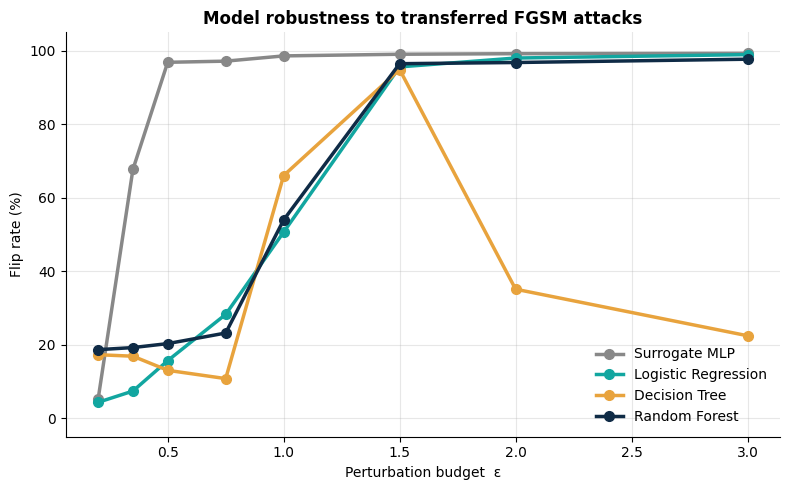

In [ ]:
import matplotlib.pyplot as plt
colors = {'Surrogate MLP':'#888888','Logistic Regression':'#12A6A0',
          'Decision Tree':'#E8A33D','Random Forest':'#0F2B46'}
fig, ax = plt.subplots(figsize=(8,5))
for m in cmp_df.columns:
    ax.plot(cmp_df.index, cmp_df[m]*100, marker='o', lw=2.5, ms=7,
            color=colors[m], label=m)
ax.set_xlabel('Perturbation budget  ε'); ax.set_ylabel('Flip rate (%)')
ax.set_title('Model robustness to transferred FGSM attacks', fontweight='bold')
ax.set_ylim(-5,105); ax.grid(alpha=0.3); ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adm_project/robustness_comparison.png', dpi=180)
plt.show()

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

cols = list(X_train.columns)
rate_feats = [c for c in cols if 'rate' in c]
ri = [cols.index(c) for c in rate_feats]
count_feats = [c for c in ['duration','src_bytes','dst_bytes','count','srv_count',
               'dst_host_count','dst_host_srv_count','wrong_fragment','hot','urgent']
               if c in cols]
ci = [cols.index(c) for c in count_feats]


rows = []
for eps in [0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    key = f'fgsm_{eps}'
    if key not in adv_store: continue
    A = scaler.inverse_transform(adv_store[key].astype(np.float64))

    neg_mag = np.clip(-A[:, ci], 0, None)
    rate_hi = np.clip(A[:, ri] - 1, 0, None)
    rate_lo = np.clip(-A[:, ri], 0, None)

    rows.append({
        'epsilon': eps,
        'mean_neg_count_feats': round((A[:, ci] < 0).sum(axis=1).mean(), 2),
        'mean_oob_rate_feats':  round(((A[:, ri] > 1) | (A[:, ri] < 0)).sum(axis=1).mean(), 2),
        'worst_neg_value':      round(neg_mag.max(), 1),
        'worst_rate_excess':    round(max(rate_hi.max(), rate_lo.max()), 3),
    })

viol_df = pd.DataFrame(rows)
viol_df.to_csv('/content/drive/MyDrive/adm_project/domain_violations.csv', index=False)
print(viol_df.to_string(index=False))
print(f"\n(counts out of {len(ci)} count features and {len(ri)} rate features)")

 epsilon  mean_neg_count_feats  mean_oob_rate_feats  worst_neg_value  worst_rate_excess
    0.20                  4.76                 6.46          21396.3              0.091
    0.35                  4.97                 6.59          37443.5              0.160
    0.50                  5.21                 7.22          53490.7              0.228
    0.75                  5.47                 7.45          80236.0              0.342
    1.00                  5.53                 7.46         106981.3              0.456
    1.50                  5.90                 7.50         160472.0              0.684
    2.00                  5.97                 7.73         213962.6              0.913
    3.00                  7.31                12.51         320943.9              1.369

(counts out of 10 count features and 15 rate features)


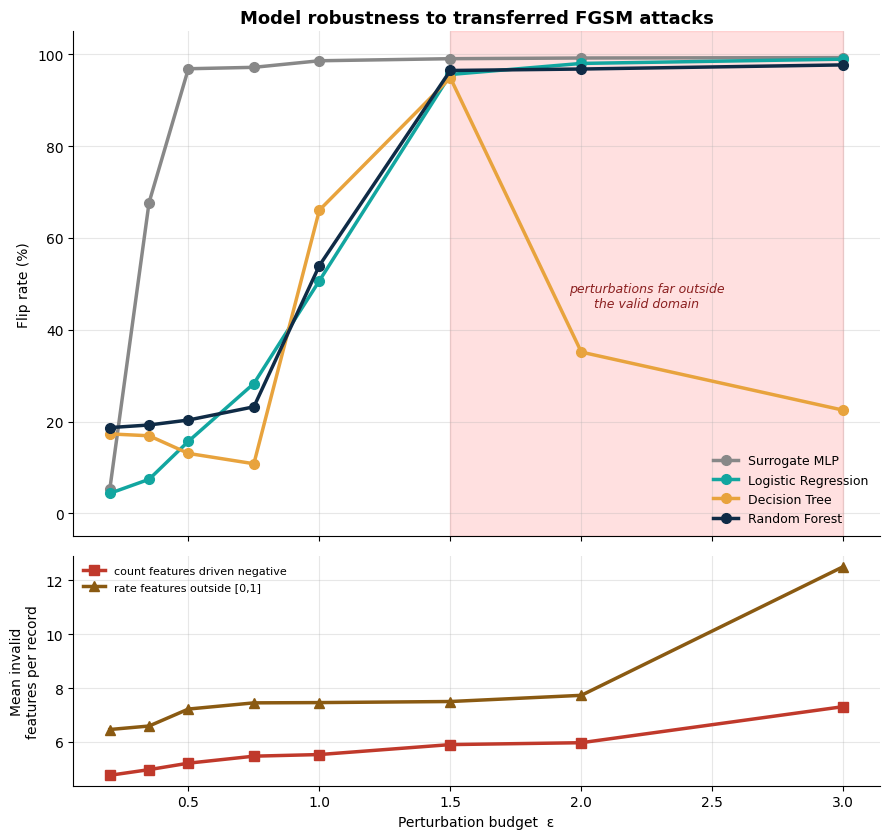

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8.5),
                               gridspec_kw={'height_ratios':[2.2,1]}, sharex=True)

colors = {'Surrogate MLP':'#888888','Logistic Regression':'#12A6A0',
          'Decision Tree':'#E8A33D','Random Forest':'#0F2B46'}
for m in cmp_df.columns:
    ax1.plot(cmp_df.index, cmp_df[m]*100, marker='o', lw=2.5, ms=7,
             color=colors[m], label=m)
ax1.axvspan(1.5, 3.0, alpha=0.12, color='red')
ax1.text(2.25, 45, 'perturbations far outside\nthe valid domain',
         ha='center', fontsize=9, color='#8B2020', style='italic')
ax1.set_ylabel('Flip rate (%)')
ax1.set_title('Model robustness to transferred FGSM attacks',
              fontweight='bold', fontsize=13)
ax1.set_ylim(-5,105); ax1.grid(alpha=0.3); ax1.legend(frameon=False, fontsize=9)
ax1.spines[['top','right']].set_visible(False)

ax2.plot(viol_df['epsilon'], viol_df['mean_neg_count_feats'], marker='s',
         lw=2.5, ms=7, color='#C0392B', label='count features driven negative')
ax2.plot(viol_df['epsilon'], viol_df['mean_oob_rate_feats'], marker='^',
         lw=2.5, ms=7, color='#8A5A12', label='rate features outside [0,1]')
ax2.set_ylabel('Mean invalid\nfeatures per record')
ax2.set_xlabel('Perturbation budget  ε')
ax2.grid(alpha=0.3); ax2.legend(frameon=False, fontsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/adm_project/robustness_and_validity.png',
            dpi=180, bbox_inches='tight')
plt.show()

In [ ]:
import pickle

with open('/content/drive/MyDrive/adm_project/adversarial_records.pkl','wb') as f:
    pickle.dump({'adv_store': adv_store,
                 'X_attack': X_attack,
                 'attack_row_ids': attack_row_ids,
                 'jsma_row_ids': jsma_row_ids,
                 'jsma_sample_idx': sample_idx,
                 'feature_names': cols,
                 'working_epsilon': 1.0}, f)

cmp_df.to_csv('/content/drive/MyDrive/adm_project/robustness_comparison.csv')
viol_df.to_csv('/content/drive/MyDrive/adm_project/domain_violations.csv', index=False)

print("Saved.")
print("Adversarial sets:", sorted(adv_store.keys()))

Saved.
Adversarial sets: ['fgsm_0.05', 'fgsm_0.1', 'fgsm_0.2', 'fgsm_0.25', 'fgsm_0.3', 'fgsm_0.35', 'fgsm_0.4', 'fgsm_0.45', 'fgsm_0.5', 'fgsm_0.75', 'fgsm_1.0', 'fgsm_1.5', 'fgsm_2.0', 'fgsm_3.0', 'jsma_0.3', 'jsma_0.5', 'jsma_1.0', 'pgd_0.05', 'pgd_0.1', 'pgd_0.2', 'pgd_0.3', 'pgd_0.35', 'pgd_0.4', 'pgd_0.45', 'pgd_0.5']


In [ ]:
TOL = 1e-6

A0 = scaler.inverse_transform(X_attack.astype(np.float64))
print("CLEAN records with tolerance:")
print("  negative count features:", (A0[:, ci] < -TOL).sum())
print("  out-of-bounds rate features:", ((A0[:, ri] > 1+TOL) | (A0[:, ri] < -TOL)).sum())
print("  most negative value:", A0[:, ci].min().round(6))

CLEAN records with tolerance:
  negative count features: 0
  out-of-bounds rate features: 0
  most negative value: -0.0


In [ ]:
rows = []
for eps in [0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    key = f'fgsm_{eps}'
    if key not in adv_store: continue
    A = scaler.inverse_transform(adv_store[key].astype(np.float64))
    neg = (A[:, ci] < -TOL)
    oob = (A[:, ri] > 1+TOL) | (A[:, ri] < -TOL)
    rows.append({
        'epsilon': eps,
        'mean_neg_count_feats': round(neg.sum(axis=1).mean(), 2),
        'mean_oob_rate_feats':  round(oob.sum(axis=1).mean(), 2),
        'pct_records_any_violation': round(((neg.any(axis=1))|(oob.any(axis=1))).mean()*100, 1),
        'worst_neg_value': round(A[:, ci].min(), 1),
    })

viol_df = pd.DataFrame(rows)
viol_df.to_csv('/content/drive/MyDrive/adm_project/domain_violations.csv', index=False)
print(viol_df.to_string(index=False))

 epsilon  mean_neg_count_feats  mean_oob_rate_feats  pct_records_any_violation  worst_neg_value
    0.20                  4.76                 6.46                      100.0         -21396.3
    0.35                  4.97                 6.59                      100.0         -37443.5
    0.50                  5.21                 7.22                      100.0         -53490.7
    0.75                  5.47                 7.45                      100.0         -80236.0
    1.00                  5.53                 7.46                      100.0        -106981.3
    1.50                  5.90                 7.50                      100.0        -160472.0
    2.00                  5.97                 7.73                      100.0        -213962.6
    3.00                  7.31                12.51                      100.0        -320943.9


In [ ]:
print('X_attack' in dir(), 'models' in dir(), 'cmp_df' in dir())

True True True


In [ ]:
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import ZooAttack
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

rf_model = models['Random Forest'][0]
rf_art = SklearnClassifier(model=rf_model)

X_attack_raw = scaler.inverse_transform(X_attack.astype(np.float64))
clean_rf = rf_model.predict(X_attack_raw)

rng = np.random.RandomState(42)
zoo_idx = rng.choice(len(X_attack_raw), size=500, replace=False)
X_zoo = X_attack_raw[zoo_idx]
X_zoo = X_zoo[rf_model.predict(X_zoo) == 1]

print(f"ZOO target set: {len(X_zoo)} records")
print(f"Attacking Random Forest directly — no surrogate, no gradients")

ZOO target set: 500 records
Attacking Random Forest directly — no surrogate, no gradients


In [ ]:
rf_art = SklearnClassifier(
    model=rf_model,
    preprocessing=(scaler.mean_.astype(np.float64),
                   scaler.scale_.astype(np.float64))
)

X_zoo_s = X_attack[zoo_idx][:150].astype(np.float64)
keep = rf_model.predict(scaler.inverse_transform(X_zoo_s)) == 1
X_zoo_s = X_zoo_s[keep]
print("Target set:", len(X_zoo_s))

t0 = time.time()
zoo = ZooAttack(classifier=rf_art, max_iter=15, nb_parallel=5,
                binary_search_steps=1, learning_rate=1e-1,
                initial_const=1.0, abort_early=False, verbose=True)
X_zoo_adv_s = zoo.generate(x=X_zoo_s)

changed = (np.abs(X_zoo_adv_s - X_zoo_s) > 1e-6).sum(axis=1)
X_zoo_adv = scaler.inverse_transform(X_zoo_adv_s)
flipped = int((rf_model.predict(X_zoo_adv) == 0).sum())
rate = flipped / len(X_zoo_s)

print(f"\nZOO: {flipped}/{len(X_zoo_s)} = {rate:.2%}  ({(time.time()-t0)/60:.1f} min)")
print(f"Mean features changed: {changed.mean():.2f} of 39")

zoo_df = pd.DataFrame([{'attack':'ZOO','access':'black-box (query only)',
                        'target':'Random Forest','n_records':len(X_zoo_s),
                        'flipped':flipped,'flip_rate':round(rate,4),
                        'mean_features_changed':round(changed.mean(),2)}])
zoo_df.to_csv('/content/drive/MyDrive/adm_project/approach2_zoo.csv', index=False)
zoo_df

Target set: 150


ZOO:   0%|          | 0/150 [00:00<?, ?it/s]


ZOO: 0/150 = 0.00%  (3.7 min)
Mean features changed: 0.00 of 39


,attack,access,target,n_records,flipped,flip_rate,mean_features_changed
0,ZOO,black-box (query only),Random Forest,150,0,0.0,0.0


In [ ]:
transfer_rf = cmp_df.loc[1.0, 'Random Forest'] * 100

a2 = pd.DataFrame([
    {'mechanism':'Transfer (surrogate → RF)','model_access':'none; substitute model',
     'flip_rate_pct': round(transfer_rf,1),
     'outcome':'Effective. FGSM eps=1.0 on neural surrogate.'},
    {'mechanism':'ZOO (query-based)','model_access':'none; queries only',
     'flip_rate_pct': 0.0,
     'outcome':'Failed to converge. Zero features perturbed on 150 records.'},
])
a2.to_csv('/content/drive/MyDrive/adm_project/approach2_summary.csv', index=False)
print(a2.to_string(index=False))
print("\nZOO estimates gradients numerically. A Random Forest's predict_proba is")
print("piecewise constant, so small perturbations return an identical probability")
print("and the estimated gradient is zero. Transfer is the viable black-box route.")

                mechanism           model_access  flip_rate_pct                                                     outcome
Transfer (surrogate → RF) none; substitute model           54.0                Effective. FGSM eps=1.0 on neural surrogate.
        ZOO (query-based)     none; queries only            0.0 Failed to converge. Zero features perturbed on 150 records.

ZOO estimates gradients numerically. A Random Forest's predict_proba is
piecewise constant, so small perturbations return an identical probability
and the estimated gradient is zero. Transfer is the viable black-box route.


In [ ]:
np.save('/content/drive/MyDrive/adm_project/zoo_adv.npy', X_zoo_adv)
np.save('/content/drive/MyDrive/adm_project/zoo_idx.npy', zoo_idx)
print("Approach 2 saved.")

Approach 2 saved.


In [ ]:
class CountingRF:
    """Wraps the Random Forest and counts every query an attacker makes."""
    def __init__(self, model):
        self.m = model
        self.n_predict = 0
        self.n_proba = 0
        self.n_rows = 0
    def reset(self):
        self.n_predict = self.n_proba = self.n_rows = 0
    def predict(self, X):
        self.n_predict += 1; self.n_rows += len(X)
        return self.m.predict(X)
    def predict_proba(self, X):
        self.n_proba += 1; self.n_rows += len(X)
        return self.m.predict_proba(X)
    @property
    def classes_(self): return self.m.classes_
    def __getattr__(self, k): return getattr(self.__dict__['m'], k)

counter = CountingRF(rf_model)
rf_art_counted = SklearnClassifier(
    model=rf_model,
    preprocessing=(scaler.mean_.astype(np.float64), scaler.scale_.astype(np.float64)))
rf_art_counted._model = counter

X_q = X_attack[zoo_idx][:150].astype(np.float64)
X_q = X_q[rf_model.predict(scaler.inverse_transform(X_q)) == 1]

counter.reset()
t0 = time.time()
zoo_q = ZooAttack(classifier=rf_art_counted, max_iter=15, nb_parallel=5,
                  binary_search_steps=1, learning_rate=1e-1,
                  initial_const=1.0, abort_early=False, verbose=True)
_ = zoo_q.generate(x=X_q)

print(f"\nRecords attacked:        {len(X_q)}")
print(f"Total model calls:       {counter.n_predict + counter.n_proba:,}")
print(f"Total rows queried:      {counter.n_rows:,}")
print(f"Queries per record:      {counter.n_rows/len(X_q):,.0f}")
print(f"Wall time:               {(time.time()-t0)/60:.1f} min")

ZOO:   0%|          | 0/150 [00:00<?, ?it/s]


Records attacked:        150
Total model calls:       4,503
Total rows queried:      25,200
Queries per record:      168
Wall time:               2.5 min


In [ ]:
print([a for a in dir(rf_art_counted) if 'model' in a.lower()])

['_model', 'model']


In [ ]:
class CountingRF:
    """Wraps the Random Forest and counts every query an attacker makes."""
    def __init__(self, model):
        self.m = model
        self.n_predict = 0
        self.n_proba = 0
        self.n_rows = 0
    def reset(self):
        self.n_predict = self.n_proba = self.n_rows = 0
    def predict(self, X):
        self.n_predict += 1; self.n_rows += len(X)
        return self.m.predict(X)
    def predict_proba(self, X):
        self.n_proba += 1; self.n_rows += len(X)
        return self.m.predict_proba(X)
    @property
    def classes_(self):
        return self.m.classes_

counter = CountingRF(rf_model)
rf_art_counted = SklearnClassifier(
    model=rf_model,
    preprocessing=(scaler.mean_.astype(np.float64), scaler.scale_.astype(np.float64)))
rf_art_counted._model = counter

X_q = X_attack[zoo_idx][:150].astype(np.float64)
X_q = X_q[rf_model.predict(scaler.inverse_transform(X_q)) == 1]

counter.reset()
t0 = time.time()
zoo_q = ZooAttack(classifier=rf_art_counted, max_iter=15, nb_parallel=5,
                  binary_search_steps=1, learning_rate=1e-1,
                  initial_const=1.0, abort_early=False, verbose=True)
_ = zoo_q.generate(x=X_q)

total_calls = counter.n_predict + counter.n_proba
print(f"\nRecords attacked:   {len(X_q)}")
print(f"Total model calls:  {total_calls:,}")
print(f"Total rows queried: {counter.n_rows:,}")
print(f"Queries per record: {counter.n_rows/len(X_q):,.0f}")
print(f"Wall time:          {(time.time()-t0)/60:.1f} min")

ZOO:   0%|          | 0/150 [00:00<?, ?it/s]


Records attacked:   150
Total model calls:  4,503
Total rows queried: 25,200
Queries per record: 168
Wall time:          2.5 min


In [2]:
from google.colab import userdata, drive
TOKEN = userdata.get('GH_TOKEN')

USERNAME = "prajwalcheela"
REPO     = "Adversarial-Patterns-in-Network-Intrusion-Classification"
EMAIL    = "prajwalcheela@gmail.com"

drive.mount('/content/drive')
!git config --global user.email "{EMAIL}"
!git config --global user.name "Prajwal Cheela"

%cd /content
!rm -rf "{REPO}"
!git clone https://{TOKEN}@github.com/{USERNAME}/{REPO}.git
print("cloned")

Mounted at /content/drive
/content
Cloning into 'Adversarial-Patterns-in-Network-Intrusion-Classification'...
cloned


In [3]:
!find /content/drive/MyDrive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
